In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


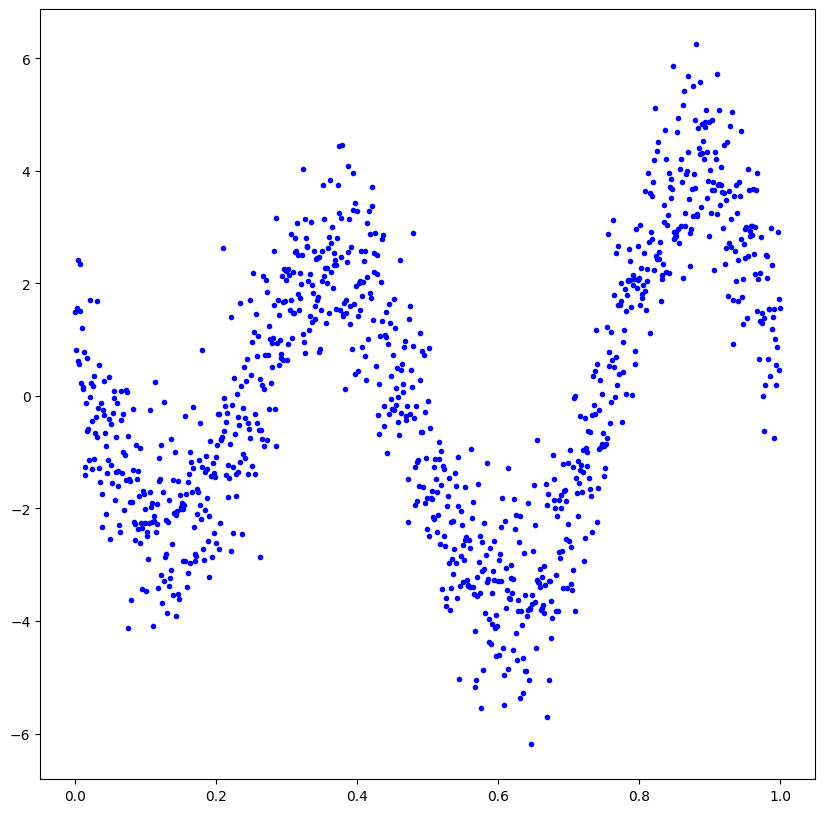

In [84]:
df = pd.read_csv('./nonLinearReg.csv',header=None)
df = df.dropna()
x = df[0].to_numpy()
y = df[1].to_numpy()


fig = plt.figure(figsize=(10,10))
plt.plot(x,y,'b.')

In [85]:
def batchGradientDescent(X, y, alpha, maxNumEpoch, grau):
    """Batch gradient descent solution."""
    # Get the number of training examples.
    N = len(y)

    # Ensuring that y is a column vector
    y = y.reshape(N,1)

    # Initialize error history with zeros.
    Jgd = np.zeros(maxNumEpoch+1)

    # Initialization of parameters (weights are generally random initialized).
    a = np.full((grau + 1, 1), -10.0)

    # Create matrix for parameter history.
    a_hist = np.zeros((grau+1, maxNumEpoch+1))
    # Initialize history matrix.
    a_hist[:, 0] = a.reshape(grau+1,)

    # Hypothesis function.
    yhat = X.dot(a)
    # Initial MSE.
    Jgd[0] = (1.0/N)*sum(np.power((y[:,0] - yhat[:,0]), 2))

    # Initialize gradient history matrix with zeros.
    grad_hist = np.zeros((grau+1, maxNumEpoch))

    # Batch gradient-descent loop.
    error = 1 # Error between consecutive epochs.
    epoch = 0 # Epoch counter.
    while(error > 1e-5 and epoch < maxNumEpoch-1):

        # Calculate the gradient vector.
        yhat = X.dot(a)
        gradients = -X.T.dot(y - yhat)

        # Update the weights.
        a = a - alpha * gradients

        # Store new weights into the matrix.
        a_hist[:, epoch+1] = a.reshape(grau+1,)

        # Calculate and store the MSE for the new weights.
        yhat = X.dot(a)
        Jgd[epoch+1] = (1.0/N)*sum(np.power((y[:,0] - yhat[:,0]), 2))

        # Calculate the error between consecutive epochs.
        error = np.abs(Jgd[epoch]-Jgd[epoch+1])

        # Update the gradient history.
        grad_hist[:, epoch] = gradients.reshape(grau+1,)

        # Increment the epoch.
        epoch += 1

    return a, a_hist, Jgd, grad_hist, epoch

In [86]:
def gerar_X(x, grau):
    X = np.ones((len(x), 1))  # a0 (bias)
    for d in range(1, grau + 1):
        X = np.c_[X, x**d]
    return X


Grau 1:
MSE (Treino) - Equação Normal: 5.336692
MSE (Validação) - Equação Normal: 5.807997
MSE (Treino) - Gradiente Descendente: 5.337229
MSE (Validação) - Gradiente Descendente: 5.799548


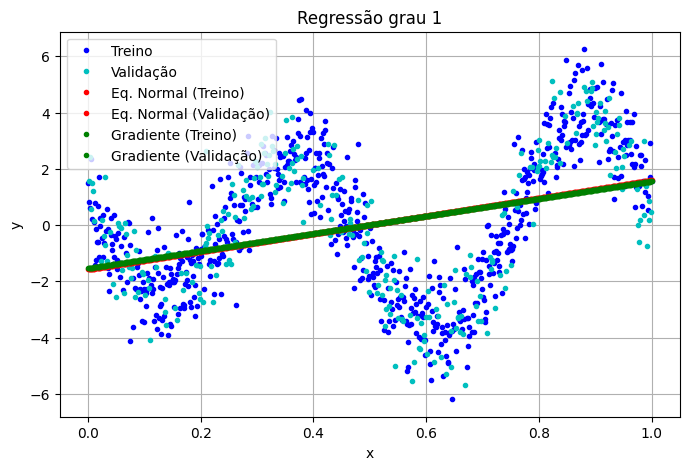

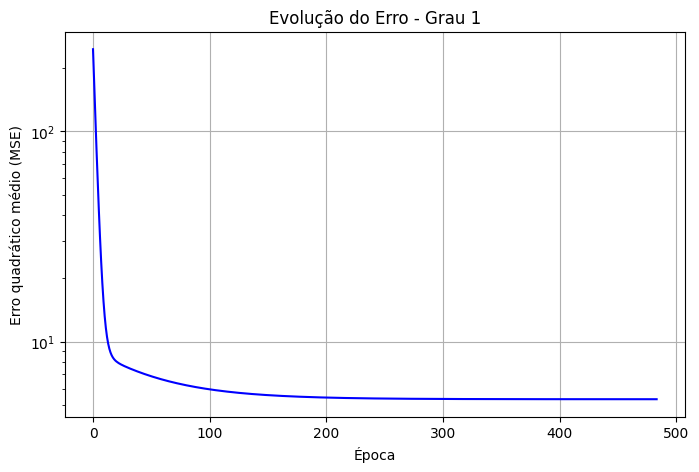


Grau 2:
MSE (Treino) - Equação Normal: 4.879084
MSE (Validação) - Equação Normal: 5.292004
MSE (Treino) - Gradiente Descendente: 7.079550
MSE (Validação) - Gradiente Descendente: 7.141362


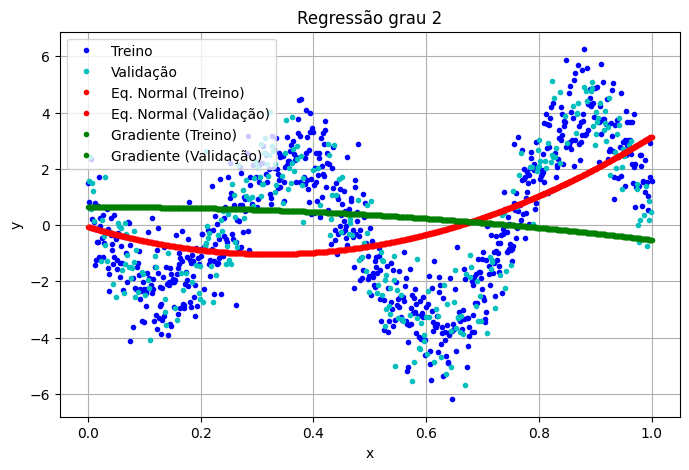

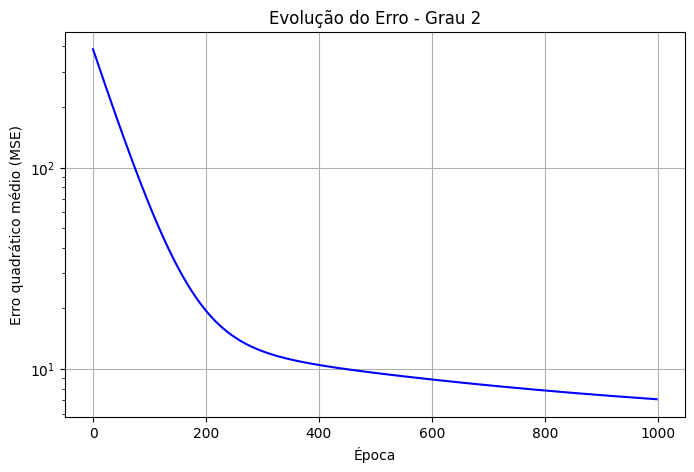


Grau 3:
MSE (Treino) - Equação Normal: 4.189345
MSE (Validação) - Equação Normal: 4.770955
MSE (Treino) - Gradiente Descendente: 165.625329
MSE (Validação) - Gradiente Descendente: 168.500489


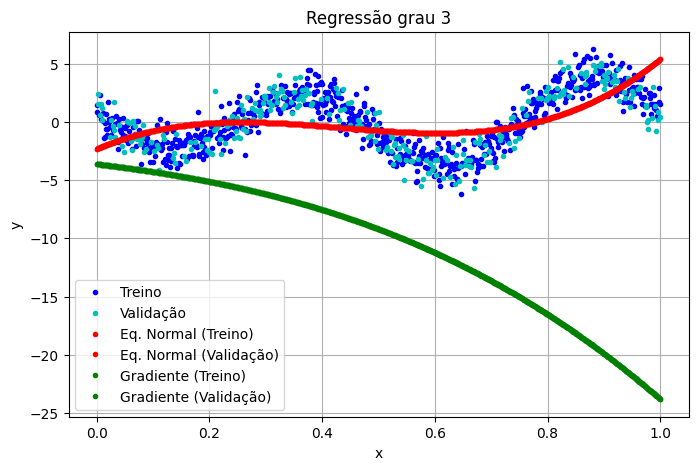

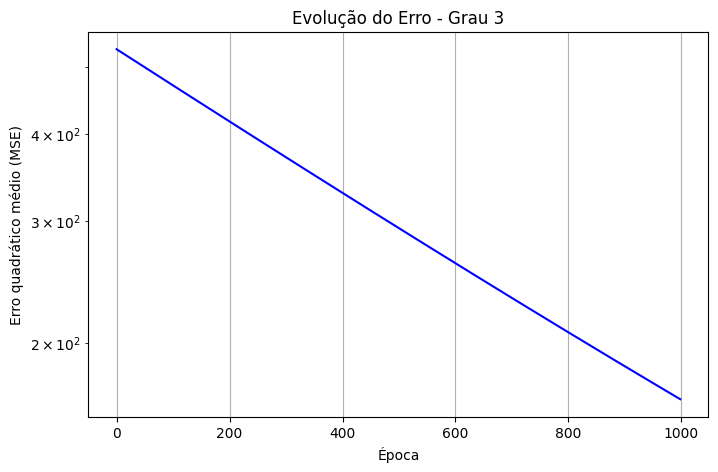


Grau 4:
MSE (Treino) - Equação Normal: 4.158132
MSE (Validação) - Equação Normal: 4.635646
MSE (Treino) - Gradiente Descendente: 658.622321
MSE (Validação) - Gradiente Descendente: 673.641729


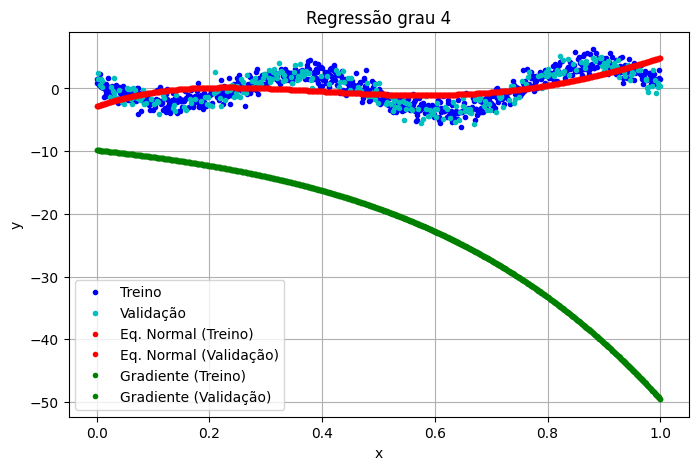

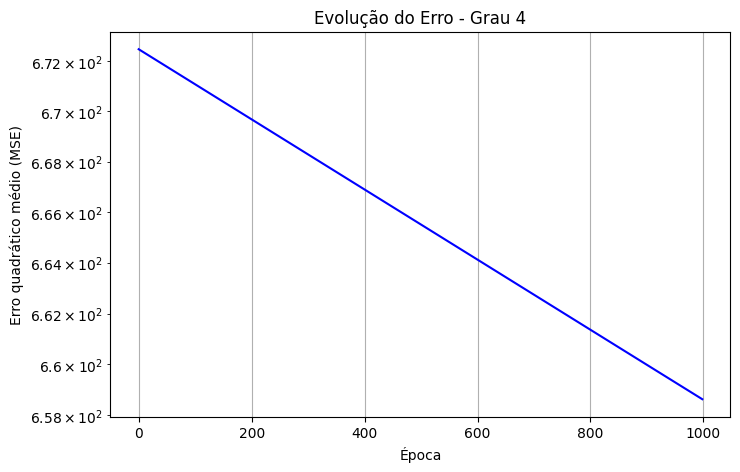

In [87]:
# Dividindo em treino e validação
x_train, x_val, y_train, y_val = train_test_split(x, y, train_size=0.7, random_state=42)

maxNumEpoch = 1000

# Testando para graus 1, 2, 3, 4
for grau in range(1, 5):
    print(f"\nGrau {grau}:")
    X_train = gerar_X(x_train, grau)
    X_val = gerar_X(x_val, grau)

    # Ajustando alpha por grau
    if grau == 1:
        alpha = 0.0002
    elif grau == 2:
        alpha = 0.00001
    elif grau == 3:
        alpha = 0.0000006
    else:
        alpha = 0.00000001

    # eq. normal
    a_normal = np.linalg.inv(X_train.T @ X_train) @ X_train.T @ y_train

    # gradiente
    a_gd, a_hist, Jgd, grad_hist, epoch = batchGradientDescent(X_train, y_train, alpha, maxNumEpoch, grau)


    y_pred_train_normal = X_train @ a_normal
    y_pred_val_normal = X_val @ a_normal

    y_pred_train_gd = X_train @ a_gd
    y_pred_val_gd = X_val @ a_gd


    mse_train_normal = np.mean((y_train - y_pred_train_normal.flatten())**2)
    mse_val_normal = np.mean((y_val - y_pred_val_normal.flatten())**2)

    mse_train_gd = np.mean((y_train - y_pred_train_gd.flatten())**2)
    mse_val_gd = np.mean((y_val - y_pred_val_gd.flatten())**2)

    print(f"MSE (Treino) - Equação Normal: {mse_train_normal:.6f}")
    print(f"MSE (Validação) - Equação Normal: {mse_val_normal:.6f}")
    print(f"MSE (Treino) - Gradiente Descendente: {mse_train_gd:.6f}")
    print(f"MSE (Validação) - Gradiente Descendente: {mse_val_gd:.6f}")

    # plot x vs h(x)
    plt.figure(figsize=(8, 5))
    plt.plot(x_train, y_train, 'b.', label='Treino')
    plt.plot(x_val, y_val, 'c.', label='Validação')
    plt.plot(x_train, y_pred_train_normal, 'r.', label='Eq. Normal (Treino)')
    plt.plot(x_val, y_pred_val_normal, 'r.', label='Eq. Normal (Validação)')
    plt.plot(x_train, y_pred_train_gd, 'g.', label='Gradiente (Treino)')
    plt.plot(x_val, y_pred_val_gd, 'g.', label='Gradiente (Validação)')
    plt.title(f'Regressão grau {grau}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid()
    plt.show()

    # plot do Erro vs Épocas
    plt.figure(figsize=(8,5))
    plt.plot(np.arange(0, epoch), Jgd[0:epoch], 'b-')
    plt.xlabel('Época')
    plt.ylabel('Erro quadrático médio (MSE)')
    plt.title(f'Evolução do Erro - Grau {grau}')
    plt.yscale('log')
    plt.grid()
    plt.show()


# O que mais aproxima da função geradora?

Resposta:  Grau 4:

MSE (Treino) - Equação Normal: 4.158132

MSE (Validação) - Equação Normal: 4.635646

MSE (Treino) - Gradiente Descendente: 658.622321

MSE (Validação) - Gradiente Descendente: 673.641729
